# a) ChatGPT

Please generate a self-contained Python script that implements the ID3 algorithm from scratch and applies it to the dataset below (target = RISK). Requirements: pure Python ID3 implementation (no sklearn decision trees), use entropy/information gain, handle categorical values (treat unknown as a category), print the final tree (nested dict), print training accuracy and per-row predictions, and produce a hierarchical matplotlib visualization saved as id3_tree.png. Organize the code into clear functions with docstrings and comments. Use pandas/numpy only if desired. Provide no extra explanatory text outside of the code.

NO.,RISK,CREDIT HISTORY,DEBT,COLLATERAL,INCOME
1,high,bad,high,none,$0 to $15k
2,high,unknown,high,none,$15 to $35k
3,moderate,unknown,low,none,$15 to $35k
4,high,unknown,low,none,$0 to $15k
5,low,unknown,low,none,over $35k
6,low,unknown,low,adequate,over $35k
7,high,bad,low,none,$0 to $15k
8,moderate,bad,low,adequate,over $35k
9,low,good,low,none,over $35k
10,low,good,high,adequate,over $35k
11,high,good,high,none,$0 to $15k
12,moderate,good,high,none,$15 to $35k
13,low,good,high,none,over $35k
14,high,bad,high,none,$15 to $35k

In [6]:
# -*- coding: utf-8 -*-
"""
Self-contained ID3 implementation and demo.
Saves a hierarchical matplotlib visualization as id3_tree.png

Usage: run this script with Python 3.6+ (pandas and matplotlib required).
This file prints:
 - the final tree as a nested dict (JSON)
 - a pretty printed hierarchical tree (nested text)
 - per-row predictions and correctness
 - training accuracy
 - saves id3_tree.png in the working directory
"""

import math
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# --- Dataset (embedded) ---
CSV = """NO.,RISK,CREDIT HISTORY,DEBT,COLLATERAL,INCOME
1,high,bad,high,none,$0 to $15k
2,high,unknown,high,none,$15 to $35k
3,moderate,unknown,low,none,$15 to $35k
4,high,unknown,low,none,$0 to $15k
5,low,unknown,low,none,over $35k
6,low,unknown,low,adequate,over $35k
7,high,bad,low,none,$0 to $15k
8,moderate,bad,low,adequate,over $35k
9,low,good,low,none,over $35k
10,low,good,high,adequate,over $35k
11,high,good,high,none,$0 to $15k
12,moderate,good,high,none,$15 to $35k
13,low,good,high,none,over $35k
14,high,bad,high,none,$15 to $35k
"""

# --- Data loading ---
def load_data_from_csv_string(csv_string):
    """
    Load CSV data from a string into a pandas DataFrame.
    Drops the NO. column if present.
    """
    from io import StringIO
    df = pd.read_csv(StringIO(csv_string))
    if 'NO.' in df.columns:
        df = df.drop(columns=['NO.'])
    return df

# --- ID3 core utilities ---
def entropy(rows, target_col):
    """
    Compute entropy of the target column for the provided rows DataFrame.
    """
    counts = rows[target_col].value_counts().to_dict()
    total = len(rows)
    if total == 0:
        return 0.0
    ent = 0.0
    for v in counts.values():
        p = v / total
        if p > 0:
            ent -= p * math.log2(p)
    return ent

def information_gain(rows, attr, target_col):
    """
    Compute information gain from splitting rows on attr.
    """
    base_entropy = entropy(rows, target_col)
    total = len(rows)
    remainder = 0.0
    # group by categorical values
    for _, group in rows.groupby(attr):
        weight = len(group) / total
        remainder += weight * entropy(group, target_col)
    return base_entropy - remainder

def majority_class(rows, target_col):
    """
    Return the most common label in target_col for rows.
    If tie, pandas.mode() returns smallest by order; that's acceptable here.
    """
    if len(rows) == 0:
        return None
    return rows[target_col].mode().iloc[0]

def id3(rows, attributes, target_col, depth=0, max_depth=None):
    """
    ID3 recursive algorithm.
    Returns a nested dict:
    - Leaf: {'leaf': label}
    - Internal: {'attribute': attr, 'nodes': {value: subtree, ...}}
    """
    # If all examples have same target -> leaf
    unique_targets = rows[target_col].unique()
    if len(unique_targets) == 1:
        return {'leaf': unique_targets[0]}
    # No attributes left or no rows -> majority class
    if not attributes or len(rows) == 0:
        return {'leaf': majority_class(rows, target_col)}
    # Max depth guard (optional)
    if max_depth is not None and depth >= max_depth:
        return {'leaf': majority_class(rows, target_col)}
    # Choose best attribute by information gain
    gains = {attr: information_gain(rows, attr, target_col) for attr in attributes}
    best_attr = max(gains, key=gains.get)
    # If best gain is zero, return leaf with majority class (can't improve)
    if gains[best_attr] <= 0:
        return {'leaf': majority_class(rows, target_col)}
    tree = {'attribute': best_attr, 'nodes': {}}
    # For every value of best_attr create subtree
    for val in rows[best_attr].unique():
        subset = rows[rows[best_attr] == val].copy()
        new_attrs = [a for a in attributes if a != best_attr]
        subtree = id3(subset, new_attrs, target_col, depth + 1, max_depth)
        tree['nodes'][val] = subtree
    return tree

# --- Prediction helpers ---
def predict_row(tree, row):
    """
    Predict single row (dict-like) using the tree.
    If unseen attribute value encountered, fallback strategies:
      1) if 'unknown' branch exists, follow it
      2) else return majority leaf among children
    """
    node = tree
    while True:
        if 'leaf' in node:
            return node['leaf']
        attr = node['attribute']
        val = row.get(attr)
        if val in node['nodes']:
            node = node['nodes'][val]
        else:
            # fallback
            if 'unknown' in node['nodes']:
                node = node['nodes']['unknown']
                continue
            # collect leaves and return majority
            child_leaves = []
            def collect_leaves(n):
                if 'leaf' in n:
                    child_leaves.append(n['leaf'])
                else:
                    for c in n['nodes'].values():
                        collect_leaves(c)
            collect_leaves(node)
            if child_leaves:
                return Counter(child_leaves).most_common(1)[0][0]
            return None

def predict_dataframe(tree, df):
    """
    Predict for each row in DataFrame df.
    Returns list of predictions.
    """
    preds = []
    for _, row in df.iterrows():
        preds.append(predict_row(tree, row.to_dict()))
    return preds

# --- Pretty print tree ---
def print_tree(tree, indent=0):
    """
    Nicely print the nested dict tree structure for human reading.
    """
    spacer = "  " * indent
    if 'leaf' in tree:
        print(f"{spacer}Leaf: {tree['leaf']}")
        return
    attr = tree['attribute']
    print(f"{spacer}{attr}?")
    for val, subtree in tree['nodes'].items():
        print(f"{spacer} -> {val}:")
        print_tree(subtree, indent + 2)

# --- Visualization (matplotlib) ---
def count_leaves(tree):
    """
    Count leaves under a tree node.
    """
    if 'leaf' in tree:
        return 1
    return sum(count_leaves(c) for c in tree['nodes'].values())

def layout_positions(tree, x_min=0.0, x_max=1.0, y_spacing=0.12, level=0, positions=None, labels=None):
    """
    Assign (x,y) positions to every node/leaf for plotting.
    Positions keyed by id(node).
    """
    if positions is None:
        positions = {}
    if labels is None:
        labels = {}
    node_id = id(tree)
    if 'leaf' in tree:
        xpos = (x_min + x_max) / 2.0
        positions[node_id] = (xpos, 1.0 - level * y_spacing)
        labels[node_id] = f"Leaf\n{tree['leaf']}"
        return positions, labels
    total = count_leaves(tree)
    cur = x_min
    for val, child in tree['nodes'].items():
        cl = count_leaves(child)
        span = (cl / total) * (x_max - x_min) if total > 0 else 0
        child_min = cur
        child_max = cur + span
        layout_positions(child, child_min, child_max, y_spacing, level + 1, positions, labels)
        cur += span
    xpos = (x_min + x_max) / 2.0
    positions[node_id] = (xpos, 1.0 - level * y_spacing)
    labels[node_id] = f"{tree['attribute']}"
    return positions, labels

def draw_tree(tree, filename="id3_tree.png"):
    """
    Draw the tree and save to filename (PNG).
    """
    positions, labels = layout_positions(tree, x_min=0.02, x_max=0.98, y_spacing=0.14)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_axis_off()
    # draw edges recursively
    def draw_edges(node):
        nid = id(node)
        if 'leaf' in node:
            return
        px, py = positions[nid]
        for val, child in node['nodes'].items():
            cid = id(child)
            cx, cy = positions[cid]
            ax.plot([px, cx], [py, cy], linewidth=1)
            # edge label at midpoint
            mx, my = (px + cx) / 2.0, (py + cy) / 2.0
            ax.text(mx, my, str(val), fontsize=8, ha='center', va='center', bbox=dict(boxstyle="round,pad=0.2", alpha=0.5))
            draw_edges(child)
    draw_edges(tree)
    # draw nodes
    for nid, (xpos, ypos) in positions.items():
        label = labels[nid]
        if label.startswith("Leaf"):
            bbox = dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
        else:
            bbox = dict(boxstyle="round4,pad=0.6", edgecolor="black", facecolor="white")
        ax.text(xpos, ypos, label, fontsize=9, ha='center', va='center', bbox=bbox)
    ax.set_title("ID3 Decision Tree")
    plt.tight_layout()
    fig.savefig(filename)
    plt.close(fig)
    return filename

# --- Main execution ---
if __name__ == "__main__":
    df = load_data_from_csv_string(CSV)
    target = "RISK"
    attributes = [c for c in df.columns if c != target]
    # Train ID3 tree
    tree = id3(df, attributes, target)
    # Print the nested dict (JSON-like)
    import json
    def tree_to_jsonable(t):
        if 'leaf' in t:
            return {'leaf': t['leaf']}
        return {'attribute': t['attribute'], 'nodes': {k: tree_to_jsonable(v) for k, v in t['nodes'].items()}}
    print(json.dumps(tree_to_jsonable(tree), indent=2))
    # Pretty print
    print("\nPretty tree:")
    print_tree(tree)
    # Per-row predictions and accuracy
    preds = predict_dataframe(tree, df)
    df_results = df.copy()
    df_results['_pred'] = preds
    df_results['_correct'] = df_results[target] == df_results['_pred']
    accuracy = df_results['_correct'].mean()
    print("\nPer-row predictions:")
    print(df_results.to_string(index=False))
    print(f"\nTraining accuracy: {accuracy*100:.2f}%")
    # Save visualization
    out = draw_tree(tree, filename="id3_tree.png")
    print(f"\nTree visualization saved to: {out}")


{
  "attribute": "INCOME",
  "nodes": {
    "$0 to $15k": {
      "leaf": "high"
    },
    "$15 to $35k": {
      "attribute": "CREDIT HISTORY",
      "nodes": {
        "unknown": {
          "attribute": "DEBT",
          "nodes": {
            "high": {
              "leaf": "high"
            },
            "low": {
              "leaf": "moderate"
            }
          }
        },
        "good": {
          "leaf": "moderate"
        },
        "bad": {
          "leaf": "high"
        }
      }
    },
    "over $35k": {
      "attribute": "CREDIT HISTORY",
      "nodes": {
        "unknown": {
          "leaf": "low"
        },
        "bad": {
          "leaf": "moderate"
        },
        "good": {
          "leaf": "low"
        }
      }
    }
  }
}

Pretty tree:
INCOME?
 -> $0 to $15k:
    Leaf: high
 -> $15 to $35k:
    CREDIT HISTORY?
     -> unknown:
        DEBT?
         -> high:
            Leaf: high
         -> low:
            Leaf: moderate
     -> good:
    

# Decision Trees and Scikit-learn

Although, at a theoretical level, is very natural for a decision tree to handle categorical variables, scikit-learn only supports binary splits and numerical variables for now.

https://scikit-learn.org/stable/modules/tree.html#tree-algorithms-id3-c4-5-c5-0-and-cart

# Homework 1, Wine Data set and Decision Trees

Using chemical analysis to determine the origin of wines.
These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. 

In [10]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
wine = datasets.load_wine()
X, y = wine.data, wine.target

# partition data with train_test_spli

#trian_size, sratify

value=0.1
gn=42

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=value,random_state=gn)

#radom_state: Controls the shuffling applied to the data before applying the split. 
#Pass an int for reproducible output across multiple function calls
#Popular integer random seeds are 0 and 42

print("train size:",len(X_train),"\ntest size:",len(X_test))

train size: 17 
test size: 161


Define the classifier, in scikit-learnrequires $always$ numerical values

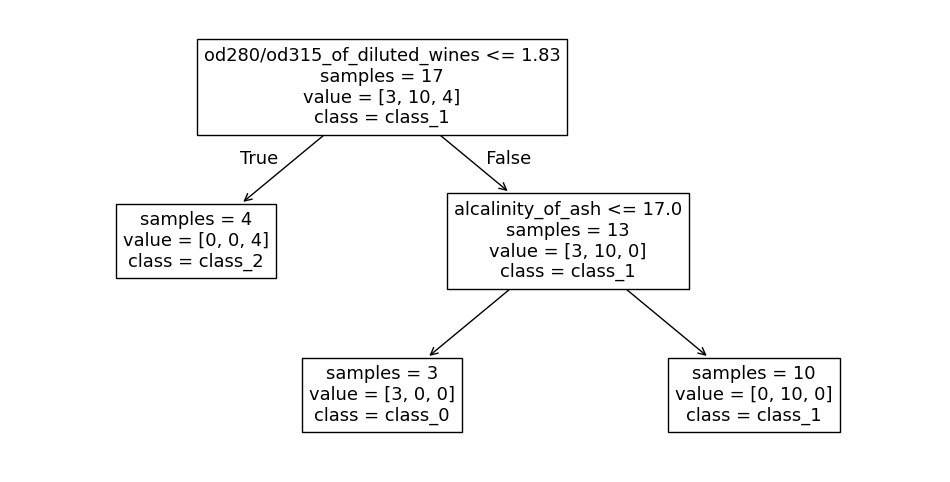

In [11]:
# 2. learn classifier
predictor = tree.DecisionTreeClassifier(criterion='entropy',random_state=gn)
predictor.fit(X_train, y_train)

# 3. plot classifier
figure = plt.figure(figsize=(12, 6))
tree.plot_tree(predictor, feature_names=wine.feature_names, class_names=wine.target_names, impurity=False)
plt.show()

In [12]:
# 4. test classifier
y_pred = predictor.predict(X_test)
print("accuracy on testing set:",  round(metrics.accuracy_score(y_test,y_pred),2))
print("depth:",predictor.get_depth())
print("number of leaves:",predictor.get_n_leaves())

accuracy on testing set: 0.69
depth: 2
number of leaves: 3
